# Exploratory Data Analysis - Artykuły BBC

In [209]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [210]:
pd.set_option('display.max_colwidth', 80)

## Pobranie danych

In [211]:
BASE_DIR = Path.cwd().parents[0]
print(BASE_DIR)
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/ruszczka/wasko/nlp_rag_proj
/home/ruszczka/wasko/nlp_rag_proj/data


In [212]:
df = pd.read_csv(DATA_DIR / "raw" / "BBC_train.csv")
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief be...,business
1,154,german business confidence slides german business confidence fell in februar...,business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed...,business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone i...,tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $...,business


## Poznanie danych

In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB


In [214]:
df.describe(include="all")

,ArticleId,Text,Category
count,1490.000000,1490,1490
unique,NaN,1440,5
top,NaN,musical treatment for capra film the classic film it s a wonderful life is t...,sport
freq,NaN,2,346
mean,1119.696644,NaN,NaN
std,641.826283,NaN,NaN
min,2.000000,NaN,NaN
25%,565.250000,NaN,NaN
50%,1112.500000,NaN,NaN
75%,1680.750000,NaN,NaN


In [215]:
df.isna().sum()

ArticleId    0
Text         0
Category     0
dtype: int64

In [216]:
df.columns

Index(['ArticleId', 'Text', 'Category'], dtype='str')

## Wstępne przetwarzanie danych

Usunięcie kolumny z Id

In [217]:
#df = df[['Text', 'Category']]
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief be...,business
1,154,german business confidence slides german business confidence fell in februar...,business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed...,business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone i...,tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $...,business


Zmiany nazw kolumn

In [218]:
df = df.rename(columns={
    "ArticleId": "article_id",
    "Text": "text",
    "Category": "category"})   
df.head()

,article_id,text,category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief be...,business
1,154,german business confidence slides german business confidence fell in februar...,business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed...,business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone i...,tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $...,business


Usunięcie powtórzeń

In [219]:
df = df.drop_duplicates(subset=["text", "category"])   
df.shape

(1440, 3)

Sprawdzenie rozłożenia kategorii

In [220]:
df[["category"]].value_counts(ascending=False).reset_index(name = "no_cat").assign(perc_of_data=(pd.col("no_cat")/df.shape[0]*100).round(2))

,category,no_cat,perc_of_data
0,sport,342,23.75
1,business,335,23.26
2,politics,266,18.47
3,entertainment,263,18.26
4,tech,234,16.25


## Tworzenie danych do analizy

Dodanie kolumn:
- "text_length"
- "text_words_count"
- "text_top_10_words"

In [221]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
ENGLISH_STOP_WORDS = ENGLISH_STOP_WORDS.union({"s", "-", "said", "new"})

df_basic = (df
.assign(text_length=pd.col("text").str.len())
.assign(text_words_count=pd.col("text").str.split().str.len())
.assign(text_top_10_words=pd.col("text").str.split().apply(lambda x: [word for word in x if word not in ENGLISH_STOP_WORDS]).apply(lambda x: pd.Series(x).value_counts().head(10).index.tolist()))
)
df_basic.insert(len(df_basic.columns)-1, "category", df_basic.pop("category"))
df_basic.head(5)

,article_id,text,text_length,text_words_count,text_top_10_words,category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief be...,1866,301,"[worldcom, accounting, mr, ebbers, cooper, lawyers, chief, fraud, charges, ms]",business
1,154,german business confidence slides german business confidence fell in februar...,2016,325,"[ifo, german, confidence, economy, business, february, index, fell, decline,...",business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed...,3104,514,"[world, countries, people, poll, economy, bbc, economic, respondents, majori...",business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone i...,3618,634,"[phone, people, mobile, use, dr, consumers, bjorn, camera, cameras, ericsson]",tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $...,2190,355,"[enron, directors, settlement, deal, $168m, financial, lawsuit, collapse, le...",business


Podstawowe statystyki

In [222]:
#df_most_common_words_by_cat =
df_basic_stats = (df_basic
.groupby('category')
.agg(
    avg_length=('text_length','mean'),
    avg_words_count=('text_words_count','mean'),
    median_length=('text_length','median'),
    median_words_count=('text_words_count','median'))
.reset_index()
)
df_basic_stats.head()

,category,avg_length,avg_words_count,median_length,median_words_count
0,business,1983.925373,334.274627,1834.0,304.0
1,entertainment,1919.433460,335.444867,1566.0,271.0
2,politics,2630.078947,451.642857,2601.5,445.0
3,sport,1903.005848,336.877193,1656.5,296.5
4,tech,2980.692308,509.222222,2738.5,461.5


Top 10 najczęściej pojawiających się słów podzielonych na kategorie

In [223]:
df_most_common_words_by_cat = (df
.assign(words_list=pd.col('text').str.split().apply(lambda x: [word for word in x if word not in ENGLISH_STOP_WORDS]))
.explode('words_list')
.groupby('category')
[['words_list']]
.value_counts()
.groupby(level=0)
.head(10)
.reset_index()
.sort_values(["category","count"], ascending=[True, False])
)
df_most_common_words_by_cat.head(50)

,category,words_list,count
0,business,mr,393
1,business,year,300
2,business,firm,242
3,business,company,240
4,business,market,235
5,business,growth,227
6,business,said.,210
7,business,government,205
8,business,economic,202
9,business,bank,194


In [224]:
df_most_common_words_by_cat.pivot(index='words_list', columns='category', values='count')

category,business,entertainment,politics,sport,tech
words_list,,,,,
.,NaN,NaN,361.0,NaN,NaN
actor,NaN,153.0,NaN,NaN,NaN
awards,NaN,148.0,NaN,NaN,NaN
band,NaN,146.0,NaN,NaN,NaN
bank,194.0,NaN,NaN,NaN,NaN
best,NaN,391.0,NaN,NaN,NaN
blair,NaN,NaN,359.0,NaN,NaN
company,240.0,NaN,NaN,NaN,NaN
cup,NaN,NaN,NaN,192.0,NaN


## Analiza

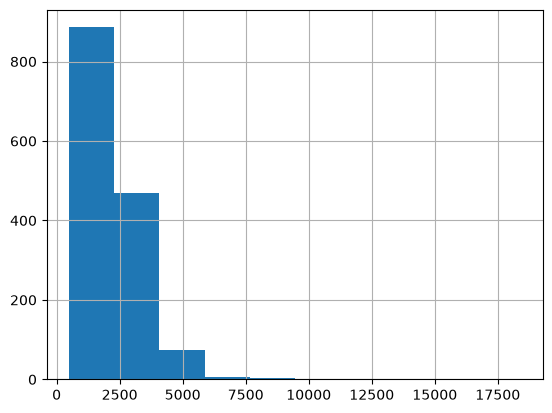

In [225]:
df_basic["text_length"].hist()
plt.show()

In [226]:
CUTOFF_TEXT_LENGTH = 6300

tmp = df_basic[df_basic["text_length"]>CUTOFF_TEXT_LENGTH].sort_values("text_length", ascending=False)
tmp["text_length"]

1057    18387
1258    13826
454     13619
364      9471
120      8826
431      7800
329      7764
264      7536
565      7121
Name: text_length, dtype: int64

In [227]:
print(df_basic[df_basic["text_length"]>CUTOFF_TEXT_LENGTH].shape)
df_basic = df_basic[df_basic["text_length"]<CUTOFF_TEXT_LENGTH]

(9, 6)


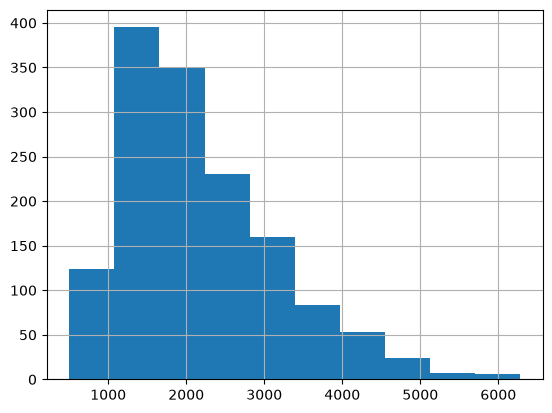

In [228]:
df_basic["text_length"].hist()
plt.show()

## Analiza wielowymiarowa

In [229]:
df_basic.head()

,article_id,text,text_length,text_words_count,text_top_10_words,category
0,1833,worldcom ex-boss launches defence lawyers defending former worldcom chief be...,1866,301,"[worldcom, accounting, mr, ebbers, cooper, lawyers, chief, fraud, charges, ms]",business
1,154,german business confidence slides german business confidence fell in februar...,2016,325,"[ifo, german, confidence, economy, business, february, index, fell, decline,...",business
2,1101,bbc poll indicates economic gloom citizens in a majority of nations surveyed...,3104,514,"[world, countries, people, poll, economy, bbc, economic, respondents, majori...",business
3,1976,lifestyle governs mobile choice faster better or funkier hardware alone i...,3618,634,"[phone, people, mobile, use, dr, consumers, bjorn, camera, cameras, ericsson]",tech
4,917,enron bosses in $168m payout eighteen former enron directors have agreed a $...,2190,355,"[enron, directors, settlement, deal, $168m, financial, lawsuit, collapse, le...",business


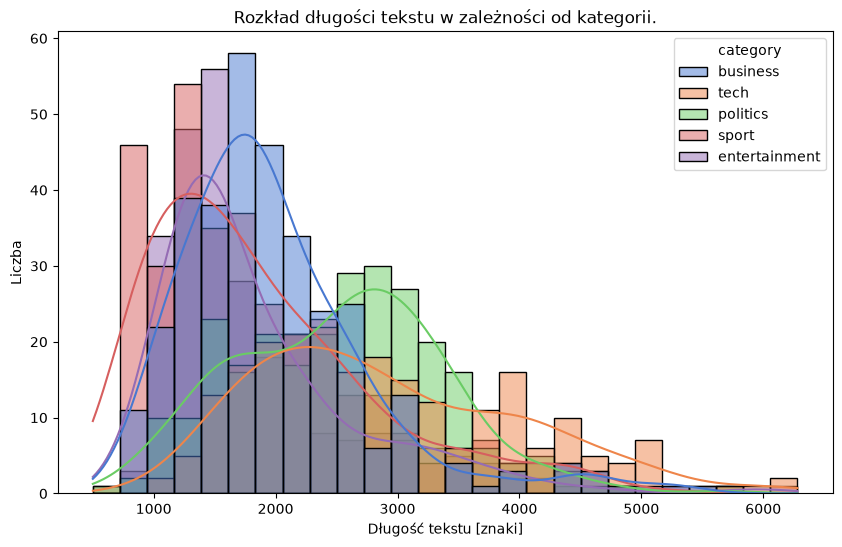

In [230]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_basic,
    x="text_length",
    hue="category",
    multiple="layer",  # {layer, dodge, stack, fill}
    palette="muted",
    kde=True,
)

plt.title("Rozkład długości tekstu w zależności od kategorii.")
plt.xlabel("Długość tekstu [znaki]")
plt.ylabel("Liczba")
plt.show()

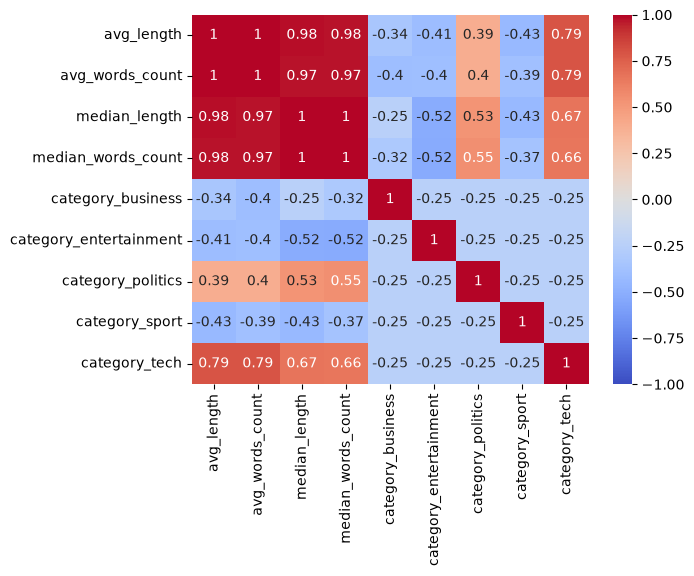

In [231]:
df_basic_stats_corr = pd.get_dummies(df_basic_stats, columns=["category"], dtype=int)
sns.heatmap(pd.get_dummies(df_basic_stats, columns=["category"], dtype=int).corr(numeric_only=True), vmin=-1, vmax=1, cmap="coolwarm", annot=True)
plt.show()

In [237]:
df_basic_corr = pd.get_dummies(df_basic, columns=["category"], dtype=int)

In [239]:
df_basic_corr.columns

Index(['article_id', 'text', 'text_length', 'text_words_count',
       'text_top_10_words', 'category_business', 'category_entertainment',
       'category_politics', 'category_sport', 'category_tech'],
      dtype='str')

## Wnioski

- duplikaty
- niezbalansowanie klas:

| category | no_cat | perc_of_data |
| :--- | :---: | :---: |
| sport | 342 | 23.75% |
| business | 335 | 23.26% |
| politics | 266 | 18.47% |
| entertainment | 263 | 18.26% |
| tech | 234 | 16.25% |

- trzeba będzie usunąć stopwords plus moje spostrzeżenia
- usunięcie za dużych tekstów (kilka)
- istnieje wpływ długości tekstu do przynależności do kategori